# Immune-Inflammatory Marker Patterns in Pediatric Acute Myocarditis

Analysis notebook. Place `myocarditis_data.csv` in the same folder and run all cells in order; every number, table, and figure reported in the manuscript and its supplement is regenerated, and the final cell asserts the key values.

**Manuscript:** "Immune Phenotyping in Pediatric Acute Myocarditis via Unsupervised Machine Learning: Implications for Risk Stratification and Precision Management" (PCCM-D-26-00245; transferred to *Critical Care Explorations*)

This notebook is the auditable analysis source for the study. It consolidates the original working notebook into one linear, top-to-bottom pipeline and distinguishes original analysis elements from analyses added in response to peer review. All reviewer-requested additions are labeled as post hoc or exploratory where appropriate. The author-confirmed source workflow limited eligibility to each patient's first documented hospitalization for acute myocarditis; later or duplicate admissions and any recorded history of prior myocarditis were excluded upstream.

**Contents**
1. Data loading, feature engineering, and software versions
2. Missingness handling and cohort definition (1,400 screened -> 1,208 clinically eligible -> 979 analyzed)
3. Missingness audit and rationale for excluding lymphocyte-subset variables
4. K-means clustering and neutral, data-descriptive phenotype labels
5. Cluster-number diagnostics, alternative algorithms, PCA, and bootstrap stability
6. MACE-or-death endpoint construction and component outcomes
7. Baseline tables, effect sizes, complication profile, and  main figures
8. Adjusted outcome model and comparison with a conventional logistic model
9. Immune-marker/cardiac-marker correlations and exploratory treatment interactions
10. CART phenotype-reproduction performance, including out-of-fold metrics
11. SII-component analysis, narrower PICU-focused endpoint, and temporal internal validation

The random seed is fixed at 42. The three-cluster solution is treated as an exploratory, clinically interpretable partition rather than a uniquely optimal latent structure.


## 1. Data loading and feature engineering

In [1]:
from pathlib import Path
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, balanced_accuracy_score,
                              silhouette_score, calinski_harabasz_score, davies_bouldin_score,
                              adjusted_rand_score, roc_auc_score)
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from scipy.stats import spearmanr, kruskal, chi2
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set(style="ticks", context="paper", font_scale=1.1)
plt.rcParams['axes.unicode_minus'] = False
RANDOM_STATE = 42
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

DATA_PATH = Path('myocarditis_data.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Place myocarditis_data.csv in the same folder as this notebook: {DATA_PATH.resolve()}")
df = pd.read_csv(DATA_PATH)
print(f"Raw rows: {df.shape[0]}, cols: {df.shape[1]}")
print(f"One row per patient: StudyID unique={df['StudyID'].is_unique}")
print({
    'Python': platform.python_version(), 'pandas': pd.__version__, 'numpy': np.__version__,
    'scikit-learn': sklearn.__version__, 'scipy': scipy.__version__,
    'statsmodels': statsmodels.__version__
})


Raw rows: 1208, cols: 86
One row per patient: StudyID unique=True
{'Python': '3.12.10', 'pandas': '2.3.3', 'numpy': '2.4.4', 'scikit-learn': '1.8.0', 'scipy': '1.17.1', 'statsmodels': '0.14.6'}


In [2]:
# ---- Publication-ready figure export -------------------
# Root cause of a legibility problem in earlier figure exports:
#   (1) Figures 2 and 3 were written with a 96-dpi tag, so the typesetter
#       rescaled them to a fraction of their intended size; and
#   (2) all figures were RGBA, which the production pipeline does not accept.
# Fix: lay figures out at their true printed width (<= 7.0 in for a full-width
# figure), export at 300 dpi, and flatten to RGB on white with no alpha.
from PIL import Image

PRINT_WIDTH_FULL = 7.0    # inches, full page width for this journal layout
EXPORT_DPI = 1200   # Journal requirement: line art must be vector or >= 1200 dpi

def save_figure(fig, stem, outdir=FIG_DIR, tight=True):
    """Save PNG + TIFF at 300 dpi, flattened to RGB (no alpha channel)."""
    outdir = Path(outdir); outdir.mkdir(exist_ok=True)
    png = outdir / f'{stem}.png'
    tif = outdir / f'{stem}.tiff'
    eps = outdir / f'{stem}.eps'
    # EPS is the primary upload format: true vector, satisfies the line-art rule.
    fig.savefig(eps, format='eps', facecolor='white', edgecolor='none',
                bbox_inches=('tight' if tight else None), pad_inches=0.02)
    fig.savefig(png, dpi=EXPORT_DPI, facecolor='white', edgecolor='none',
                bbox_inches=('tight' if tight else None), pad_inches=0.02)
    im = Image.open(png)
    if im.mode in ('RGBA', 'LA', 'P'):
        bg = Image.new('RGB', im.size, (255, 255, 255))
        bg.paste(im, mask=im.convert('RGBA').split()[-1])
        im = bg
    else:
        im = im.convert('RGB')
    im.save(png, dpi=(EXPORT_DPI, EXPORT_DPI))
    im.save(tif, compression='tiff_lzw', dpi=(EXPORT_DPI, EXPORT_DPI))
    w_in = im.size[0] / EXPORT_DPI
    print(f'{stem}: {im.size[0]}x{im.size[1]} px | {w_in:.2f} in wide @ {EXPORT_DPI} dpi | mode={im.mode}')
    assert im.mode == 'RGB', 'figure must be RGB'
    assert w_in <= PRINT_WIDTH_FULL + 0.05, f'{stem} is wider than the printed column'
    return png, tif

plt.rcParams.update({
    'font.size': 7, 'axes.titlesize': 8, 'axes.labelsize': 7,
    'xtick.labelsize': 6.5, 'ytick.labelsize': 6.5, 'legend.fontsize': 6.5,
    'figure.dpi': 110, 'savefig.bbox': 'tight', 'savefig.pad_inches': 0.02,
    # Journal requirement: captions and in-figure variables must be Helvetica or Arial.
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

In [3]:
# Ensure numeric types for lab values used anywhere downstream
numeric_cols = ['NEUT','LYM','PLT','IgG','IgM','IgA','C3','C4','PCT','LDH','EOS',
                'ALT','Scr','CKMB','cTnT','NTproBNP','Age','Sex']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

epsilon = 1e-9
df['NLR'] = df['NEUT'] / (df['LYM'] + epsilon)
df['SII'] = (df['PLT'] * df['NEUT']) / (df['LYM'] + epsilon)

CORE_FEATURES = ['IgG', 'IgM', 'IgA', 'C3', 'C4', 'PCT', 'LDH', 'NLR', 'SII']
print("Nine-marker immune-inflammatory panel:", CORE_FEATURES)


Nine-marker immune-inflammatory panel: ['IgG', 'IgM', 'IgA', 'C3', 'C4', 'PCT', 'LDH', 'NLR', 'SII']


## 2. Missingness handling and cohort definition

The author-confirmed source workflow retained only each patient's first documented hospitalization for acute myocarditis. Later or duplicate admissions and patients with any recorded history of prior myocarditis were excluded before the supplied 1,208-row patient-level extract was created. StudyID is unique in the accompanying data file, confirming one row per patient; the file does not contain the upstream encounter history used to adjudicate first hospitalization.

The retained pipeline required at least 5 of the 9 panel variables to be observed. Thus, patients missing 5-9 variables were excluded, whereas those missing 1-4 variables were retained and median-imputed. This is the implemented rule that reproduces the analytic N=979 and the 491/447/41 cluster split; it corrects the inconsistent thresholds described in the original manuscript.


In [4]:
THRESHOLD = len(CORE_FEATURES) * 0.5  # i.e., require >=5 of 9 present
analysis_df = df.dropna(thresh=THRESHOLD, subset=CORE_FEATURES).copy()
excluded_df = df[~df.index.isin(analysis_df.index)].copy()

imputer = SimpleImputer(strategy='median')
analysis_df[CORE_FEATURES] = imputer.fit_transform(analysis_df[CORE_FEATURES])

print(f"Analytic cohort: N = {len(analysis_df)}  (manuscript reports 979)")
print(f"Excluded for missingness: N = {len(excluded_df)}  (manuscript Fig 1 reports 229)")


Analytic cohort: N = 979  (manuscript reports 979)
Excluded for missingness: N = 229  (manuscript Fig 1 reports 229)


## 3. Missingness audit

In [5]:
print("Missingness among the 1,208 pre-exclusion patients, per panel variable:")
print((df[CORE_FEATURES].isna().mean()*100).round(1).sort_values(ascending=False))

print("\nMissingness among the 229 EXCLUDED patients:")
print((excluded_df[CORE_FEATURES].isna().mean()*100).round(1).sort_values(ascending=False))

n_missing_per_pt = analysis_df[CORE_FEATURES].isna().sum(axis=1)  # will be 0 post-imputation; recompute pre-impute


Missingness among the 1,208 pre-exclusion patients, per panel variable:
LDH    26.6
IgA    23.6
NLR    23.3
SII    23.3
C4     19.5
C3     18.9
IgM    18.9
PCT    18.8
IgG    18.7
dtype: float64

Missingness among the 229 EXCLUDED patients:
IgA    100.0
C4      99.1
C3      99.1
IgG     98.3
IgM     98.3
PCT     53.7
LDH     47.2
NLR     47.2
SII     47.2
dtype: float64


In [6]:
# Recompute pre-imputation missingness within the retained analytic cohort
pre_impute = df.loc[analysis_df.index, CORE_FEATURES]
n_missing_per_pt = pre_impute.isna().sum(axis=1)
print("Distribution of # missing panel variables per patient, among the 979 retained patients:")
print(n_missing_per_pt.value_counts().sort_index())
print(f"\nPatients with >=1 imputed value: {(n_missing_per_pt>=1).sum()} "
      f"({100*(n_missing_per_pt>=1).mean():.1f}% of analytic cohort)")
for c in CORE_FEATURES:
    nmiss = pre_impute[c].isna().sum()
    print(f"  {c}: {nmiss} missing ({100*nmiss/len(analysis_df):.1f}%)")


Distribution of # missing panel variables per patient, among the 979 retained patients:
0    533
1    244
2    130
3     58
4     14
Name: count, dtype: int64

Patients with >=1 imputed value: 446 (45.6% of analytic cohort)
  IgG: 1 missing (0.1%)
  IgM: 3 missing (0.3%)
  IgA: 56 missing (5.7%)
  C3: 1 missing (0.1%)
  C4: 8 missing (0.8%)
  PCT: 104 missing (10.6%)
  LDH: 213 missing (21.8%)
  NLR: 174 missing (17.8%)
  SII: 174 missing (17.8%)


### Lymphocyte-subset variables - data-availability rationale

CD3/CD4/CD8/CD19/NK variables were considered as biologically relevant candidate markers but were not retained in the nine-marker clustering panel because their missingness was substantially higher. The available records do not establish a prospectively registered marker-selection plan; the analysis is therefore described as exploratory rather than prespecified.


In [7]:
TCELL_VARS = ['CD3T','CD4T','CD8T','CD19','NK','CD3TPER','CD4TPER','CD19PER','NKPER']
print("Missingness of lymphocyte-subset variables (dropped from panel):")
print((df[TCELL_VARS].isna().mean()*100).round(1))
print(f"\n(Compare to the 9 panel variables actually used: {(df[CORE_FEATURES].isna().mean()*100).round(1).mean():.1f}% average missingness)")


Missingness of lymphocyte-subset variables (dropped from panel):
CD3T       45.8
CD4T       45.8
CD8T       45.8
CD19       45.8
NK         45.8
CD3TPER    45.8
CD4TPER    45.8
CD19PER    45.8
NKPER      44.9
dtype: float64

(Compare to the 9 panel variables actually used: 21.3% average missingness)


## Figure 1: cohort flow and explicit missingness rule


In [1]:
##Figure 1 were drawn using PowerPoint.

## 4. K-means clustering (k=3) and neutral, data-descriptive phenotype labels


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(analysis_df[CORE_FEATURES])

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
analysis_df['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# Deterministic labels describe the relative marker pattern; they do not diagnose immune deficiency
# or prove a mechanistic inflammatory state.
medians = analysis_df.groupby('Cluster_ID')[CORE_FEATURES].median()
alpha_id = medians['SII'].idxmax()
beta_id = medians['IgG'].idxmin()
gamma_id = list({0, 1, 2} - {alpha_id, beta_id})[0]

cluster_map = {alpha_id: 'Alpha: High-Inflammation-Marker',
               beta_id: 'Beta: Lower-Humoral-Marker',
               gamma_id: 'Gamma: Intermediate-Marker'}
analysis_df['Cluster_Name'] = analysis_df['Cluster_ID'].map(cluster_map)

ORDER = ['Beta: Lower-Humoral-Marker', 'Gamma: Intermediate-Marker',
         'Alpha: High-Inflammation-Marker']
print(analysis_df['Cluster_Name'].value_counts().reindex(ORDER))
print("Expected split from the submitted analysis: Beta 491 / Gamma 447 / Alpha 41")


Cluster_Name
Beta: Lower-Humoral-Marker         491
Gamma: Intermediate-Marker         447
Alpha: High-Inflammation-Marker     41
Name: count, dtype: int64
Expected split from the submitted analysis: Beta 491 / Gamma 447 / Alpha 41


## 5. Cluster-number diagnostics

The original exploratory analysis used k=3 because it produced a compact, clinically interpretable partition. Post hoc diagnostics requested by the reviewers do not identify k=3 as a uniquely optimal solution: the silhouette coefficient is low and has no peak at k=3, and the elbow curve lacks a sharp inflection. These results are reported to define the limits of the clustering claim.


In [10]:
cluster_validation_results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    labels = km.labels_
    cluster_validation_results.append({
        'k': k,
        'WCSS': km.inertia_,
        'Silhouette': silhouette_score(X_scaled, labels),
        'Calinski_Harabasz': calinski_harabasz_score(X_scaled, labels),
        'Davies_Bouldin': davies_bouldin_score(X_scaled, labels)
    })
cluster_validation_df = pd.DataFrame(cluster_validation_results)
print(cluster_validation_df.round(3))
print("\nNote: silhouette is essentially flat across k=2-5 (0.198-0.215) with no peak at k=3;")
print("the elbow curve decreases smoothly with no sharp inflection at any k.")


   k      WCSS  Silhouette  Calinski_Harabasz  Davies_Bouldin
0  2  7439.051       0.198            180.185           1.854
1  3  6329.265       0.203            191.347           1.488
2  4  5548.251       0.210            191.124           1.339
3  5  4965.929       0.215            188.541           1.129
4  6  4774.531       0.158            164.518           1.541
5  7  4228.363       0.156            175.573           1.347
6  8  3943.896       0.160            171.185           1.292

Note: silhouette is essentially flat across k=2-5 (0.198-0.215) with no peak at k=3;
the elbow curve decreases smoothly with no sharp inflection at any k.


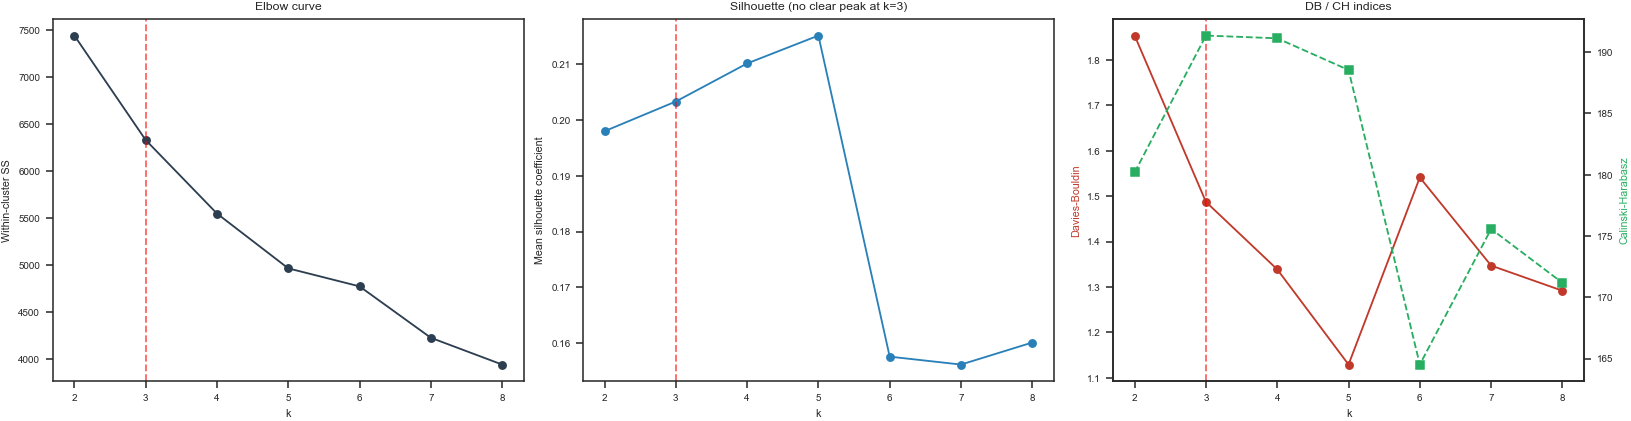

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(cluster_validation_df['k'], cluster_validation_df['WCSS'], 'o-', color='#2c3e50')
axes[0].axvline(3, color='red', linestyle='--', alpha=0.6)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Within-cluster SS'); axes[0].set_title('Elbow curve')

axes[1].plot(cluster_validation_df['k'], cluster_validation_df['Silhouette'], 'o-', color='#2980b9')
axes[1].axvline(3, color='red', linestyle='--', alpha=0.6)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Mean silhouette coefficient')
axes[1].set_title('Silhouette (no clear peak at k=3)')

ax2 = axes[2]; ax2b = ax2.twinx()
ax2.plot(cluster_validation_df['k'], cluster_validation_df['Davies_Bouldin'], 'o-', color='#c0392b')
ax2b.plot(cluster_validation_df['k'], cluster_validation_df['Calinski_Harabasz'], 's--', color='#27ae60')
ax2.axvline(3, color='red', linestyle='--', alpha=0.6)
ax2.set_xlabel('k'); ax2.set_ylabel('Davies-Bouldin', color='#c0392b')
ax2b.set_ylabel('Calinski-Harabasz', color='#27ae60'); ax2.set_title('DB / CH indices')
plt.tight_layout()
plt.show()
# (exploratory view only; the publication-quality version is
#  written by the supplemental-figure section at the end of this notebook)


## 6. Alternative unsupervised methods and PCA

Gaussian mixture modeling and DBSCAN are sensitivity analyses added after peer review. They do not recover a comparable three-cluster partition; the BIC-optimal GMM favors six components and agreement with K-means is poor. PCA is used only for visualization. These results argue against presenting the K-means partition as a uniquely correct latent taxonomy.


In [12]:
# GMM: BIC across k=2-6
gmm_bics = []
for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=5).fit(X_scaled)
    gmm_bics.append((k, gmm.bic(X_scaled)))
    print(f"GMM k={k}: BIC={gmm.bic(X_scaled):.1f}")
best_k_gmm = min(gmm_bics, key=lambda t: t[1])[0]
print(f"BIC-optimal GMM k = {best_k_gmm}  (K-means used k=3)")

gmm3 = GaussianMixture(n_components=3, random_state=RANDOM_STATE, n_init=5).fit(X_scaled)
gmm_labels = gmm3.predict(X_scaled)
ari_gmm = adjusted_rand_score(analysis_df['Cluster_ID'], gmm_labels)
print(f"\nARI (K-means k=3 vs. GMM k=3): {ari_gmm:.3f}  (1.0 = identical, 0 = random)")


GMM k=2: BIC=12339.1
GMM k=3: BIC=10790.6
GMM k=4: BIC=9902.6
GMM k=5: BIC=9627.7
GMM k=6: BIC=9489.0
BIC-optimal GMM k = 6  (K-means used k=3)

ARI (K-means k=3 vs. GMM k=3): 0.045  (1.0 = identical, 0 = random)


In [13]:
# DBSCAN: scan eps for the eps that yields exactly 3 clusters
best_eps = None
for eps in np.arange(0.8, 4.0, 0.1):
    db = DBSCAN(eps=eps, min_samples=9).fit(X_scaled)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    if n_clusters == 3:
        best_eps = eps
        break

if best_eps:
    db = DBSCAN(eps=best_eps, min_samples=9).fit(X_scaled)
    mask = db.labels_ != -1
    ari_db = adjusted_rand_score(analysis_df['Cluster_ID'][mask], db.labels_[mask])
    print(f"DBSCAN (eps={best_eps:.1f}, only eps in [0.8,4.0) giving 3 clusters): "
          f"{ (db.labels_==-1).sum()} noise points; ARI vs K-means (non-noise) = {ari_db:.3f}")
else:
    print("No eps in [0.8, 4.0) produced exactly 3 DBSCAN clusters (typical at 1.0-2.0: 1-2 clusters "
          "with 15-40% noise) -- DBSCAN does not recover a comparable 3-cluster structure here.")


DBSCAN (eps=0.8, only eps in [0.8,4.0) giving 3 clusters): 620 noise points; ARI vs K-means (non-noise) = -0.055


PCA: PC1+PC2 explain 46.8% of total variance


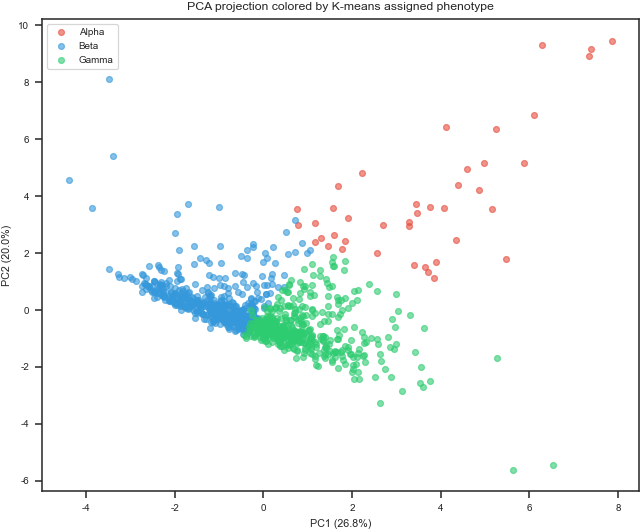

In [14]:
# PCA visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
print(f"PCA: PC1+PC2 explain {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance")

colors = {'Alpha: High-Inflammation-Marker': '#e74c3c', 'Beta: Lower-Humoral-Marker': '#3498db',
          'Gamma: Intermediate-Marker': '#2ecc71'}
plt.figure(figsize=(6, 5))
for cl, col in colors.items():
    mask = analysis_df['Cluster_Name'] == cl
    plt.scatter(pcs[mask, 0], pcs[mask, 1], s=15, alpha=0.6, color=col, label=cl.split(':')[0])
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(); plt.title('PCA projection colored by K-means assigned phenotype')
plt.tight_layout()
plt.show()
# (exploratory view only; the publication-quality version is
#  written by the supplemental-figure section at the end of this notebook)


## 7. Bootstrap stability analysis

This post hoc analysis refits centroids in 200 bootstrap resamples, relabels the original cohort with each fitted solution, and compares membership with the original partition. The whole-partition adjusted Rand index and Alpha-cluster Jaccard overlap are reported separately because the small Alpha group is particularly vulnerable to instability.


In [15]:
np.random.seed(RANDOM_STATE)
B = 200
n = X_scaled.shape[0]
orig_labels = analysis_df['Cluster_ID'].values
orig_alpha_members = set(np.where(orig_labels == alpha_id)[0])

aris, alpha_jaccards = [], []
for b in range(B):
    idx = np.random.choice(n, n, replace=True)
    km_b = KMeans(n_clusters=3, random_state=b, n_init=10).fit(X_scaled[idx])
    boot_labels_full = km_b.predict(X_scaled)  # relabel the ORIGINAL cohort with bootstrap centroids
    aris.append(adjusted_rand_score(orig_labels, boot_labels_full))

    medians_b = pd.DataFrame(X_scaled, columns=CORE_FEATURES).assign(cl=boot_labels_full).groupby('cl')[CORE_FEATURES].median()
    boot_alpha_id = medians_b['SII'].idxmax()
    boot_alpha_members = set(np.where(boot_labels_full == boot_alpha_id)[0])
    jacc = len(orig_alpha_members & boot_alpha_members) / len(orig_alpha_members | boot_alpha_members)
    alpha_jaccards.append(jacc)

aris = np.array(aris); alpha_jaccards = np.array(alpha_jaccards)
print(f"Bootstrap (B={B}) whole-partition ARI: mean={aris.mean():.3f}, SD={aris.std():.3f}, "
      f"range=[{aris.min():.3f}, {aris.max():.3f}]")
print(f"Alpha-cluster Jaccard overlap across bootstraps: mean={alpha_jaccards.mean():.3f}, "
      f"SD={alpha_jaccards.std():.3f}  (Alpha n={len(orig_alpha_members)})")


Bootstrap (B=200) whole-partition ARI: mean=0.769, SD=0.220, range=[-0.002, 0.992]
Alpha-cluster Jaccard overlap across bootstraps: mean=0.570, SD=0.349  (Alpha n=41)


## 8. Endpoint construction: in-hospital MACE-or-death composite

The rates reported in an earlier version of this analysis (34.1% / 17.7% / 10.1%) correspond to six recorded cardiac event flags plus in-hospital death. The  manuscript names this explicitly as an in-hospital MACE-or-death composite. Vasoactive-infusion or mechanical-circulatory-support use was not separately captured as a component in the available analysis data. A narrower PICU-focused composite is evaluated later as a post hoc sensitivity analysis.


In [16]:
MACE_COMPONENTS = ['Fulminant myocarditis', 'Cardiogenic shock', 'Cardiac arrest',
                    'Ventricular tachycardia', 'CAVB', 'HF']
for c in MACE_COMPONENTS:
    analysis_df[c] = pd.to_numeric(analysis_df[c], errors='coerce').fillna(0)

analysis_df['MACE'] = analysis_df[MACE_COMPONENTS].max(axis=1)
analysis_df['Death'] = analysis_df['Discharge Condition'].apply(lambda x: 1 if str(x) == 'Died' else 0)
analysis_df['Composite_Outcome'] = analysis_df[['MACE', 'Death']].max(axis=1)

print("MACE (6 components only, no death) rate by phenotype:")
print((analysis_df.groupby('Cluster_Name')['MACE'].mean()*100).reindex(ORDER).round(1))
print("\nComposite_Outcome (MACE OR death) rate by phenotype -- this is what the manuscript reports as \"MACE\":")
print((analysis_df.groupby('Cluster_Name')['Composite_Outcome'].mean()*100).reindex(ORDER).round(1))
print("(manuscript reports Beta 17.7% / Gamma 10.1% / Alpha 34.1%)")
print(f"\nIn-hospital deaths: {int(analysis_df['Death'].sum())} / {len(analysis_df)}")


MACE (6 components only, no death) rate by phenotype:
Cluster_Name
Beta: Lower-Humoral-Marker         17.5
Gamma: Intermediate-Marker          9.8
Alpha: High-Inflammation-Marker    34.1
Name: MACE, dtype: float64

Composite_Outcome (MACE OR death) rate by phenotype -- this is what the manuscript reports as "MACE":
Cluster_Name
Beta: Lower-Humoral-Marker         17.7
Gamma: Intermediate-Marker         10.1
Alpha: High-Inflammation-Marker    34.1
Name: Composite_Outcome, dtype: float64
(manuscript reports Beta 17.7% / Gamma 10.1% / Alpha 34.1%)

In-hospital deaths: 8 / 979


## 9. Table 1 (baseline characteristics) and complication breakdown

In [17]:
# ============================================================================
# Table S1 (rebuilt): baseline characteristics on OBSERVED values only.
#
# In the submitted version these statistics were computed on the median-imputed
# panel, which forced the imputed constant to become the group median wherever
# missingness was substantial (e.g. LDH was reported as 287.00 in all three
# groups). The nine panel variables are therefore now summarized from the raw
# extract; imputation is retained only where it is required, i.e. to compute
# distances for clustering.
# ============================================================================
raw = df.loc[analysis_df.index].copy()
for c in raw.columns:
    if c not in ('StudyID', 'Discharge Condition'):
        raw[c] = pd.to_numeric(raw[c], errors='coerce')
raw['NLR'] = raw['NEUT'] / raw['LYM']
raw['SII'] = raw['PLT'] * raw['NEUT'] / raw['LYM']
raw['Cluster_Name'] = analysis_df['Cluster_Name'].values

def eps_squared(stat, n_total, k_groups):
    return max(0.0, (stat - k_groups + 1) / (n_total - k_groups))

def med_iqr(s, dec=None):
    s = s.dropna()
    if len(s) == 0:
        return 'NA'
    if dec is None:
        dec = 1 if abs(s.median()) >= 100 else 2
    return f'{s.median():.{dec}f} ({s.quantile(.25):.{dec}f}-{s.quantile(.75):.{dec}f})'

TABLE_S1_VARS = [
    ('Age', 'Age, yr'), ('Wt', 'Weight, kg'), ('Ht', 'Height, cm'),
    ('T', 'Temperature, C'), ('P', 'Heart rate, beats/min'),
    ('RR', 'Respiratory rate, breaths/min'),
    ('WBC', 'WBC, x10^9/L'), ('NEUT', 'Neutrophils, x10^9/L'),
    ('LYM', 'Lymphocytes, x10^9/L'), ('EOS', 'Eosinophils, x10^9/L'),
    ('PLT', 'Platelets, x10^9/L'), ('Hb', 'Hemoglobin, g/L'),
    ('NLR', 'NLR'), ('SII', 'SII'),
    ('ALT', 'ALT, U/L'), ('Scr', 'Creatinine, umol/L'), ('LDH', 'LDH, U/L'),
    ('CKMB', 'CK-MB, U/L'), ('cTnT', 'cTnT, ug/L'), ('NTproBNP', 'NT-proBNP, pg/mL'),
    ('IgG', 'IgG, g/L'), ('IgM', 'IgM, g/L'), ('IgA', 'IgA, g/L'),
    ('C3', 'C3, g/L'), ('C4', 'C4, g/L'),
    ('HsCRP', 'hs-CRP, mg/L'), ('PCT', 'PCT, ng/mL'), ('ESR', 'ESR, mm/h'),
]

rows = []
for col, label in TABLE_S1_VARS:
    gs = [raw.loc[raw.Cluster_Name == g, col].dropna() for g in ORDER]
    stat, p = kruskal(*gs)
    n_tot = sum(len(g) for g in gs)
    row = {'Characteristic': label}
    for name, g in zip(['Beta', 'Gamma', 'Alpha'], gs):
        row[name] = med_iqr(g)
        row[f'n_{name}'] = len(g)
    row['P'] = '<0.001' if p < 0.001 else f'{p:.3f}'
    row['Epsilon-squared'] = round(eps_squared(stat, n_tot, 3), 3)
    row['Missing, %'] = round(raw[col].isna().mean() * 100, 1)
    rows.append(row)

tableS1 = pd.DataFrame(rows)
tableS1.to_csv('TableS1_baseline_observed.csv', index=False, encoding='utf-8-sig')
print(tableS1.to_string(index=False))

from scipy.stats import chi2_contingency as _chi2ct
sex_ct = pd.crosstab(raw.Cluster_Name, raw.Sex).reindex(ORDER)
sex_p = _chi2ct(sex_ct)[1]
print('\nMale sex, n (%):', {g: f'{int(sex_ct.loc[g,1])} ({sex_ct.loc[g,1]/sex_ct.loc[g].sum()*100:.1f}%)'
                             for g in ORDER}, f'| P={sex_p:.3f}')

               Characteristic                 Beta  n_Beta               Gamma  n_Gamma                  Alpha  n_Alpha      P  Epsilon-squared  Missing, %
                      Age, yr     2.76 (0.72-4.65)     491    5.90 (3.92-8.73)      447       6.85 (4.19-9.80)       41 <0.001            0.233         0.0
                   Weight, kg   13.50 (9.00-18.00)     491 20.30 (16.00-30.00)      447    22.00 (18.00-29.00)       41 <0.001            0.222         0.0
                   Height, cm 95.00 (70.00-110.00)     491 118.0 (104.2-135.0)      447    125.0 (110.0-140.0)       41 <0.001            0.234         0.0
               Temperature, C  36.70 (36.40-37.10)     491 36.60 (36.30-37.00)      447    36.80 (36.50-37.60)       41  0.004            0.009         0.0
        Heart rate, beats/min  115.0 (102.0-130.0)     491  105.0 (92.0-118.0)      447    118.0 (102.0-130.0)       41 <0.001            0.071         0.0
Respiratory rate, breaths/min  26.00 (24.00-32.00)     491 24.00

### Table S2: quantifying the median-imputation artifact

In [18]:
# ============================================================================
# Table S2: observed-value vs median-imputed summaries.
#
# This quantifies the artifact directly. Wherever a variable had substantial
# missingness, the imputed constant (the cohort median) became the reported
# group median, collapsing between-group separation and attenuating the effect
# size while the P value stayed small because the test was run at the full
# imputed n.
# ============================================================================
cmp_rows = []
for col in CORE_FEATURES + ['CKMB', 'HsCRP', 'cTnT', 'EOS']:
    obs = [raw.loc[raw.Cluster_Name == g, col].dropna() for g in ORDER]
    fill = raw[col].median()
    imp = [raw.loc[raw.Cluster_Name == g, col].fillna(fill) for g in ORDER]
    s_o, p_o = kruskal(*obs); s_i, p_i = kruskal(*imp)
    cmp_rows.append({
        'Variable': col,
        'Missing, %': round(raw[col].isna().mean() * 100, 1),
        'Obs Beta': round(obs[0].median(), 2), 'Obs Gamma': round(obs[1].median(), 2),
        'Obs Alpha': round(obs[2].median(), 2),
        'Obs eps2': round(eps_squared(s_o, sum(len(g) for g in obs), 3), 3),
        'Imp Beta': round(imp[0].median(), 2), 'Imp Gamma': round(imp[1].median(), 2),
        'Imp Alpha': round(imp[2].median(), 2),
        'Imp eps2': round(eps_squared(s_i, sum(len(g) for g in imp), 3), 3),
    })
tableS2 = pd.DataFrame(cmp_rows)
tableS2.to_csv('TableS2_observed_vs_imputed.csv', index=False, encoding='utf-8-sig')
print(tableS2.to_string(index=False))

print('\nCohort medians used as the imputation constant:')
for col in ['LDH', 'SII', 'NLR', 'HsCRP', 'CKMB']:
    print(f'  {col}: {raw[col].median():.2f}  (missing {raw[col].isna().mean()*100:.1f}%)')
print('\nThese are exactly the values reported as group medians in the submitted Table S1,')
print('which is how three identical LDH medians of 287.00 arose.')

Variable  Missing, %  Obs Beta  Obs Gamma  Obs Alpha  Obs eps2  Imp Beta  Imp Gamma  Imp Alpha  Imp eps2
     IgG         0.1      6.71       9.86       9.30     0.404      6.72       9.86       9.30     0.403
     IgM         0.3      0.84       1.21       1.00     0.221      0.84       1.21       1.00     0.220
     IgA         5.7      0.57       1.29       1.20     0.380      0.64       1.28       1.20     0.357
      C3         0.1      0.87       1.11       1.08     0.309      0.87       1.11       1.08     0.309
      C4         0.8      0.20       0.27       0.26     0.164      0.20       0.27       0.25     0.163
     PCT        10.6      0.12       0.10       0.52     0.037      0.12       0.11       0.51     0.033
     LDH        21.8    300.00     268.00     290.00     0.021    287.00     287.00     287.00     0.015
     NLR        17.8      0.82       1.37      12.02     0.191      1.10       1.13      12.02     0.157
     SII        17.8    245.93     385.68    4403.33   

### Adams-Stokes syndrome and the composite definition

In [19]:
# ============================================================================
# Components of the composite outcome. The source data also
# contains an Adams-Stokes syndrome indicator that was not among the six
# components. We check whether excluding it changed the composite.
# ============================================================================
raw['AdamsStokes'] = raw['Adams-Stokes syndrome'].fillna(0).astype(int) \
    if 'Adams-Stokes syndrome' in raw.columns \
    else df.loc[analysis_df.index, [c for c in df.columns if 'Stokes' in c][0]].fillna(0).astype(int).values

n_as = int(pd.Series(raw['AdamsStokes']).sum())
already = int(((pd.Series(raw['AdamsStokes']).values == 1) &
               (analysis_df['Composite_Outcome'].values == 1)).sum())
print(f'Adams-Stokes syndrome recorded in {n_as}/{len(raw)} analytic patients.')
print(f'Of these, {already} already met the composite through another component or death.')
alt_composite = ((analysis_df['Composite_Outcome'].values == 1) |
                 (pd.Series(raw['AdamsStokes']).values == 1)).astype(int)
print('Composite rate if Adams-Stokes were added as a seventh component:')
for g in ORDER:
    m = (analysis_df['Cluster_Name'] == g).values
    print(f'  {g}: {alt_composite[m].mean()*100:.1f}% '
          f'(primary definition {analysis_df.loc[m, "Composite_Outcome"].mean()*100:.1f}%)')
assert (alt_composite == analysis_df['Composite_Outcome'].values).all() or already == n_as, \
    'Adams-Stokes adds events; the manuscript statement must be '

Adams-Stokes syndrome recorded in 11/979 analytic patients.
Of these, 11 already met the composite through another component or death.
Composite rate if Adams-Stokes were added as a seventh component:
  Beta: Lower-Humoral-Marker: 17.7% (primary definition 17.7%)
  Gamma: Intermediate-Marker: 10.1% (primary definition 10.1%)
  Alpha: High-Inflammation-Marker: 34.1% (primary definition 34.1%)


In [20]:
print("Complication rate by phenotype (verified, matches Figure 2A):")
complication_table = (analysis_df.groupby('Cluster_Name')[MACE_COMPONENTS].mean()*100).reindex(ORDER).round(1).T
complication_table.to_csv('complication_table_verified.csv', encoding='utf-8-sig')
print(complication_table)


Complication rate by phenotype (verified, matches Figure 2A):
Cluster_Name             Beta: Lower-Humoral-Marker  \
Fulminant myocarditis                           4.5   
Cardiogenic shock                               4.9   
Cardiac arrest                                  1.8   
Ventricular tachycardia                         3.1   
CAVB                                            1.0   
HF                                             13.6   

Cluster_Name             Gamma: Intermediate-Marker  \
Fulminant myocarditis                           2.2   
Cardiogenic shock                               2.7   
Cardiac arrest                                  0.2   
Ventricular tachycardia                         3.6   
CAVB                                            0.9   
HF                                              5.8   

Cluster_Name             Alpha: High-Inflammation-Marker  
Fulminant myocarditis                               12.2  
Cardiogenic shock                               

## Figure 2: component outcomes and composite event rates


Figure_2: 7966x3530 px | 6.64 in wide @ 1200 dpi | mode=RGB


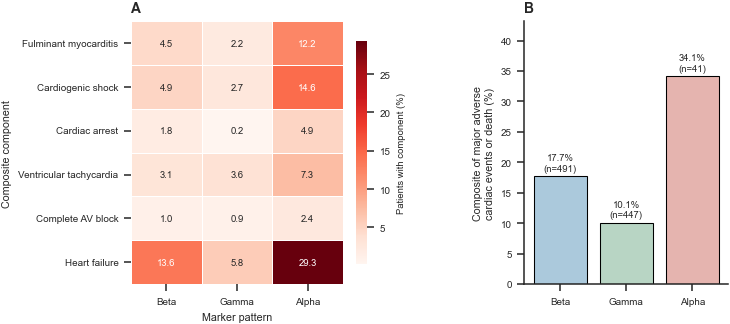

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(PRINT_WIDTH_FULL, 3.1),
                         gridspec_kw={'width_ratios': [1.3, 1], 'wspace': 0.55})
plot_comp = complication_table[['Beta: Lower-Humoral-Marker',
                                'Gamma: Intermediate-Marker',
                                'Alpha: High-Inflammation-Marker']]
plot_comp.index = ['Fulminant myocarditis', 'Cardiogenic shock', 'Cardiac arrest',
                   'Ventricular tachycardia', 'Complete AV block', 'Heart failure']
sns.heatmap(plot_comp, annot=True, fmt='.1f', cmap='Reds', ax=axes[0],
            cbar_kws={'label': 'Patients with component (%)', 'shrink': 0.85},
            annot_kws={'size': 6.2}, linewidths=0.4, linecolor='white')
axes[0].set_xlabel('Marker pattern'); axes[0].set_ylabel('Composite component')
axes[0].set_xticklabels(['Beta', 'Gamma', 'Alpha'], rotation=0)
axes[0].set_yticklabels(plot_comp.index, rotation=0)
axes[0].set_title('A', loc='left', fontsize=9, weight='bold')
axes[0].figure.axes[-1].yaxis.label.set_size(6.2)

rates = (analysis_df.groupby('Cluster_Name')['Composite_Outcome'].mean()*100).reindex(ORDER)
counts = analysis_df['Cluster_Name'].value_counts().reindex(ORDER)
bars = axes[1].bar(['Beta', 'Gamma', 'Alpha'], rates.values,
                   color=['#abc9dc', '#b8d5c4', '#e5b4af'], edgecolor='black', linewidth=0.7)
axes[1].set_ylabel('Composite of major adverse\ncardiac events or death (%)')
axes[1].set_title('B', loc='left', fontsize=9, weight='bold')
for bar, rate, n in zip(bars, rates.values, counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, rate+0.9, f'{rate:.1f}%\n(n={n})',
                 ha='center', fontsize=6.2)
axes[1].set_ylim(0, max(rates.values)+9)
sns.despine(ax=axes[1])
save_figure(fig, 'Figure_2')
plt.show()

## 10. Multivariable logistic regression (forest plot; eFigure 3)

In [22]:
analysis_df['Is_Alpha'] = (analysis_df['Cluster_Name'] == 'Alpha: High-Inflammation-Marker').astype(int)
analysis_df['Is_Beta'] = (analysis_df['Cluster_Name'] == 'Beta: Lower-Humoral-Marker').astype(int)
analysis_df['cTnT'] = analysis_df['cTnT'].fillna(analysis_df['cTnT'].median())
analysis_df['log_cTnT'] = np.log1p(analysis_df['cTnT'])
analysis_df['Age'] = analysis_df['Age'].fillna(analysis_df['Age'].median())
analysis_df['Sex'] = analysis_df['Sex'].fillna(analysis_df['Sex'].median())

reg_df = analysis_df[['Composite_Outcome','Is_Alpha','Is_Beta','Age','Sex','log_cTnT']].dropna()
X = sm.add_constant(reg_df[['Is_Alpha','Is_Beta','Age','Sex','log_cTnT']])
y = reg_df['Composite_Outcome']
model = sm.Logit(y, X).fit(disp=0)

print(model.summary())
params, conf = model.params, model.conf_int()
for var in ['Is_Alpha','Is_Beta','Age','Sex','log_cTnT']:
    OR = np.exp(params[var]); lo, hi = np.exp(conf.loc[var])
    print(f"{var}: OR={OR:.2f} [{lo:.2f}-{hi:.2f}], p={model.pvalues[var]:.4g}")
print("(manuscript reports Alpha OR 3.53 [1.45-8.56], Beta OR 2.10 [1.26-3.52], cTnT OR 95.59)")


                           Logit Regression Results                           
Dep. Variable:      Composite_Outcome   No. Observations:                  979
Model:                          Logit   Df Residuals:                      973
Method:                           MLE   Df Model:                            5
Date:                Mon, 17 Aug 2026   Pseudo R-squ.:                  0.2404
Time:                        16:26:44   Log-Likelihood:                -313.22
converged:                       True   LL-Null:                       -412.35
Covariance Type:            nonrobust   LLR p-value:                 6.646e-41
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0117      0.432     -6.967      0.000      -3.859      -2.165
Is_Alpha       1.2612      0.452      2.789      0.005       0.375       2.148
Is_Beta        0.7437      0.262      2.835      0.0

## 10a. Does phenotype information add to a conventional logistic model?

This section tests whether the marker patterns add information beyond simpler clinical statistics. We do not claim that simple methods "failed." Instead, we compare a conventional model (age, sex, log-cTnT) with the same model plus the two phenotype indicators. The likelihood-ratio test is an in-sample nested-model comparison. The five-fold analysis refits imputation, scaling, K-means, phenotype labels, and logistic models within each training fold before predicting the held-out fold.


In [23]:
base_X = sm.add_constant(reg_df[['Age','Sex','log_cTnT']])
base_model = sm.Logit(y, base_X).fit(disp=0)
lr_stat = 2 * (model.llf - base_model.llf)
lr_p = chi2.sf(lr_stat, df=2)
base_auc_app = roc_auc_score(y, base_model.predict(base_X))
phen_auc_app = roc_auc_score(y, model.predict(X))
print(f"Nested likelihood-ratio test for adding phenotype indicators: chi2={lr_stat:.2f}, df=2, p={lr_p:.4g}")
print(f"Apparent AUC: conventional={base_auc_app:.3f}, +phenotype={phen_auc_app:.3f}")

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_base = np.full(len(analysis_df), np.nan)
oof_pheno = np.full(len(analysis_df), np.nan)
fold_rows = []
raw_panel = df.loc[analysis_df.index, CORE_FEATURES].copy()
raw_cov = df.loc[analysis_df.index, ['Age','Sex','cTnT']].copy()
y_all = analysis_df['Composite_Outcome'].astype(int).to_numpy()

for fold, (train, test) in enumerate(outer_cv.split(raw_panel, y_all), start=1):
    panel_imputer = SimpleImputer(strategy='median').fit(raw_panel.iloc[train])
    panel_train = panel_imputer.transform(raw_panel.iloc[train])
    panel_test = panel_imputer.transform(raw_panel.iloc[test])
    scaler_fold = StandardScaler().fit(panel_train)
    z_train = scaler_fold.transform(panel_train); z_test = scaler_fold.transform(panel_test)
    km_fold = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(z_train)
    train_labels_raw = km_fold.labels_
    train_panel_df = pd.DataFrame(panel_train, columns=CORE_FEATURES)
    train_panel_df['cluster'] = train_labels_raw
    fold_medians = train_panel_df.groupby('cluster')[CORE_FEATURES].median()
    a_id = fold_medians['SII'].idxmax(); b_id = fold_medians['IgG'].idxmin()
    g_id = list({0,1,2}-{a_id,b_id})[0]
    fold_map = {a_id:'Alpha', b_id:'Beta', g_id:'Gamma'}
    lab_train = pd.Series(train_labels_raw).map(fold_map)
    lab_test = pd.Series(km_fold.predict(z_test)).map(fold_map)

    cov_train = raw_cov.iloc[train].copy(); cov_test = raw_cov.iloc[test].copy()
    for c in ['Age','Sex','cTnT']:
        med = cov_train[c].median()
        cov_train[c] = cov_train[c].fillna(med); cov_test[c] = cov_test[c].fillna(med)
    cov_train['log_cTnT'] = np.log1p(cov_train['cTnT'])
    cov_test['log_cTnT'] = np.log1p(cov_test['cTnT'])
    xb_train = cov_train[['Age','Sex','log_cTnT']].to_numpy()
    xb_test = cov_test[['Age','Sex','log_cTnT']].to_numpy()
    xp_train = np.column_stack([xb_train, (lab_train=='Alpha').astype(int), (lab_train=='Beta').astype(int)])
    xp_test = np.column_stack([xb_test, (lab_test=='Alpha').astype(int), (lab_test=='Beta').astype(int)])
    m_base = LogisticRegression(max_iter=2000).fit(xb_train, y_all[train])
    m_pheno = LogisticRegression(max_iter=2000).fit(xp_train, y_all[train])
    pb = m_base.predict_proba(xb_test)[:,1]; pp = m_pheno.predict_proba(xp_test)[:,1]
    oof_base[test] = pb; oof_pheno[test] = pp
    fold_rows.append({'fold':fold, 'AUC_conventional':roc_auc_score(y_all[test], pb),
                      'AUC_plus_phenotype':roc_auc_score(y_all[test], pp)})

cv_model_df = pd.DataFrame(fold_rows)
cv_model_df.to_csv('outcome_model_nested_cv.csv', index=False, encoding='utf-8-sig')
auc_base_cv = roc_auc_score(y_all, oof_base); auc_pheno_cv = roc_auc_score(y_all, oof_pheno)
print(cv_model_df.round(3).to_string(index=False))
print(f"Pooled out-of-fold AUC: conventional={auc_base_cv:.3f}, +phenotype={auc_pheno_cv:.3f}, difference={auc_pheno_cv-auc_base_cv:.3f}")


Nested likelihood-ratio test for adding phenotype indicators: chi2=12.55, df=2, p=0.001878
Apparent AUC: conventional=0.779, +phenotype=0.791
 fold  AUC_conventional  AUC_plus_phenotype
    1             0.791               0.779
    2             0.805               0.834
    3             0.761               0.762
    4             0.774               0.814
    5             0.709               0.805
Pooled out-of-fold AUC: conventional=0.754, +phenotype=0.779, difference=0.025


## 11. Immune marker × cardiac injury marker correlation matrix 

In [24]:
INJURY_VARS = ['CKMB','cTnT','ALT','Scr','NTproBNP']
for v in INJURY_VARS:
    analysis_df[v] = pd.to_numeric(analysis_df[v], errors='coerce')

corr_table = pd.DataFrame(index=CORE_FEATURES, columns=INJURY_VARS, dtype=float)
for iv in CORE_FEATURES:
    for jv in INJURY_VARS:
        sub = analysis_df[[iv, jv]].dropna()
        rho, p = spearmanr(sub[iv], sub[jv])
        corr_table.loc[iv, jv] = rho
corr_table.to_csv('correlation_matrix_verified.csv', encoding='utf-8-sig')
print(corr_table.round(2))

print("\nSpecific marker pairs of interest:")
for iv, jv in [('IgG','CKMB'), ('NLR','CKMB'), ('IgG','cTnT'), ('NLR','cTnT')]:
    sub = analysis_df[[iv, jv]].dropna()
    rho, p = spearmanr(sub[iv], sub[jv])
    print(f"  {iv} vs {jv}: rho={rho:.3f}, p={p:.4g}")


     CKMB  cTnT   ALT   Scr  NTproBNP
IgG -0.23 -0.17 -0.23  0.38     -0.21
IgM -0.09 -0.30 -0.21  0.11     -0.18
IgA -0.19 -0.11 -0.21  0.45     -0.17
C3  -0.27 -0.20 -0.27  0.06     -0.12
C4  -0.04 -0.15 -0.15  0.06     -0.18
PCT  0.15  0.12  0.17  0.09      0.17
LDH  0.50  0.27  0.35 -0.14      0.27
NLR -0.04  0.03 -0.05  0.29      0.10
SII -0.06  0.05 -0.06  0.20      0.12

Specific marker pairs of interest:
  IgG vs CKMB: rho=-0.231, p=2.905e-10
  NLR vs CKMB: rho=-0.045, p=0.2246
  IgG vs cTnT: rho=-0.174, p=4.109e-08
  NLR vs cTnT: rho=0.034, p=0.2933


## 12. Phenotype-by-treatment interaction (post hoc, exploratory)

These observational interaction models test statistical heterogeneity of association, not treatment efficacy. Treatment was not randomized or protocolized; estimates are susceptible to confounding by indication and should not guide therapy.


In [25]:
for treat in ['Used_Steroids','Used_IVIG']:
    analysis_df[treat] = pd.to_numeric(analysis_df[treat], errors='coerce').fillna(0)
    d = analysis_df.copy()
    d['Alpha_x_treat'] = d['Is_Alpha'] * d[treat]
    d['Beta_x_treat'] = d['Is_Beta'] * d[treat]
    cols = ['Composite_Outcome','Is_Alpha','Is_Beta',treat,'Alpha_x_treat','Beta_x_treat','Age','Sex','log_cTnT']
    reg = d[cols].dropna()
    Xi = sm.add_constant(reg[['Is_Alpha','Is_Beta',treat,'Alpha_x_treat','Beta_x_treat','Age','Sex','log_cTnT']])
    yi = reg['Composite_Outcome']
    m = sm.Logit(yi, Xi).fit(disp=0)
    print(f"--- Treatment = {treat} (N={len(reg)}, events={int(yi.sum())}) ---")
    for term in ['Alpha_x_treat','Beta_x_treat']:
        OR = np.exp(m.params[term]); lo, hi = np.exp(m.conf_int().loc[term]); p = m.pvalues[term]
        print(f"  {term}: OR={OR:.2f} [{lo:.2f}-{hi:.2f}], interaction p={p:.4f}")
    print()

print("Note: Beta x IVIG showed a borderline (p=0.057), non-significant trend toward HIGHER MACE risk,")
print("which may reflect confounding by indication and is not evidence of benefit,")
print("causal treatment effects cannot be inferred from these models.")


--- Treatment = Used_Steroids (N=979, events=146) ---
  Alpha_x_treat: OR=1.55 [0.20-12.12], interaction p=0.6763
  Beta_x_treat: OR=1.16 [0.43-3.16], interaction p=0.7690

--- Treatment = Used_IVIG (N=979, events=146) ---
  Alpha_x_treat: OR=1.35 [0.20-9.15], interaction p=0.7572
  Beta_x_treat: OR=2.72 [0.97-7.64], interaction p=0.0572

Note: Beta x IVIG showed a borderline (p=0.057), non-significant trend toward HIGHER MACE risk,
which may reflect confounding by indication and is not evidence of benefit,
causal treatment effects cannot be inferred from these models.


## 13. CART phenotype-reproduction classifier

The tree approximates K-means labels; it is not a diagnostic gold standard and does not directly predict MACE. We report both apparent full-cohort performance (used to display the final tree) and five-fold out-of-fold performance. Sensitivity, specificity, PPV, and NPV are one-vs-rest metrics for phenotype-label reproduction.


In [26]:
TREE_FEATURES = ['IgG','SII','C3','NLR']
X_tree = analysis_df[TREE_FEATURES]
y_tree = analysis_df['Cluster_Name']

clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, min_samples_leaf=20)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
y_pred_cv = cross_val_predict(clf, X_tree, y_tree, cv=cv, method='predict')
cv_acc = accuracy_score(y_tree, y_pred_cv)
cv_bal_acc = balanced_accuracy_score(y_tree, y_pred_cv)
print(f"Five-fold out-of-fold accuracy: {cv_acc*100:.1f}%")
print(f"Five-fold out-of-fold balanced accuracy: {cv_bal_acc*100:.1f}%")

clf.fit(X_tree, y_tree)
y_pred = clf.predict(X_tree)
acc = accuracy_score(y_tree, y_pred)
print(f"Apparent full-cohort accuracy: {acc*100:.1f}%")
print("Feature importances:", dict(zip(TREE_FEATURES, clf.feature_importances_.round(4))))
print("NLR was an available candidate but was not selected by the fitted tree.")


Five-fold out-of-fold accuracy: 81.9%
Five-fold out-of-fold balanced accuracy: 71.1%
Apparent full-cohort accuracy: 82.9%
Feature importances: {'IgG': np.float64(0.576), 'SII': np.float64(0.1429), 'C3': np.float64(0.2812), 'NLR': np.float64(0.0)}
NLR was an available candidate but was not selected by the fitted tree.


In [27]:
labels = ['Alpha: High-Inflammation-Marker', 'Beta: Lower-Humoral-Marker',
          'Gamma: Intermediate-Marker']

def sens_spec_ppv_npv(cm, i):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    return tp/(tp+fn), tn/(tn+fp), tp/(tp+fp), tn/(tn+fn)

rows = []
for evaluation, predictions in [('Out-of-fold', y_pred_cv), ('Apparent', y_pred)]:
    cm_eval = confusion_matrix(y_tree, predictions, labels=labels)
    for i, name in enumerate(['Alpha','Beta','Gamma']):
        sens, spec, ppv, npv = sens_spec_ppv_npv(cm_eval, i)
        rows.append({'Evaluation': evaluation, 'Phenotype': name, 'Sensitivity': sens,
                     'Specificity': spec, 'PPV': ppv, 'NPV': npv})
performance_df = pd.DataFrame(rows)
performance_df.to_csv('CART_phenotype_reproduction_metrics.csv', index=False, encoding='utf-8-sig')
print(performance_df.assign(**{c: (performance_df[c]*100).round(1)
      for c in ['Sensitivity','Specificity','PPV','NPV']}).to_string(index=False))

cm_cv = confusion_matrix(y_tree, y_pred_cv, labels=labels)
cm_cv_df = pd.DataFrame(cm_cv, index=['True_Alpha','True_Beta','True_Gamma'],
                        columns=['Pred_Alpha','Pred_Beta','Pred_Gamma'])
cm_cv_df.to_csv('confusion_matrix_out_of_fold.csv', encoding='utf-8-sig')
print("\nOut-of-fold confusion matrix:\n", cm_cv_df)


 Evaluation Phenotype  Sensitivity  Specificity  PPV  NPV
Out-of-fold     Alpha         46.3         99.6 82.6 97.7
Out-of-fold      Beta         84.7         82.0 82.5 84.2
Out-of-fold     Gamma         82.1         84.0 81.2 84.8
   Apparent     Alpha         70.7         99.9 96.7 98.7
   Apparent      Beta         93.9         72.7 77.6 92.2
   Apparent     Gamma         72.0         93.8 90.7 80.0

Out-of-fold confusion matrix:
             Pred_Alpha  Pred_Beta  Pred_Gamma
True_Alpha          19         11          11
True_Beta            1        416          74
True_Gamma           3         77         367


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure_3: 7969x7718 px | 6.64 in wide @ 1200 dpi | mode=RGB


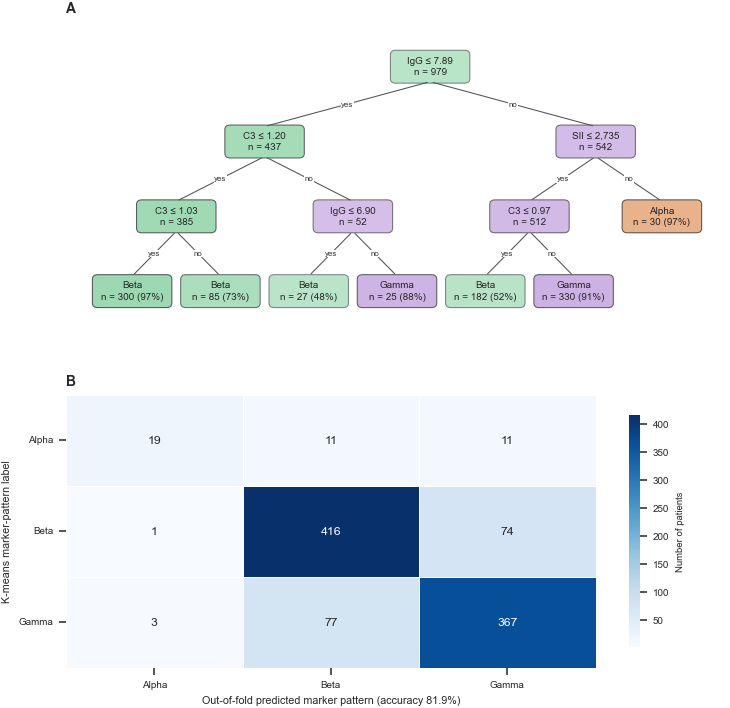

In [28]:
# Panels are stacked so the tree can use the full printed width. The node text
# is condensed to two lines: sklearn's default four-line nodes overrun the slot
# width once a depth-3 tree is scaled to a journal column, which is why the
# submitted Figure 3 was unreadable.
from matplotlib.patches import FancyBboxPatch as _FBP

TREE_PALETTE = {'Alpha': '#e8a87c', 'Beta': '#8fd4a8', 'Gamma': '#c4a5e0'}

def draw_compact_tree(clf, feature_names, class_names, ax, fontsize=6.5):
    t = clf.tree_
    depth_of = {}
    def set_depth(node, d):
        depth_of[node] = d
        if t.children_left[node] != -1:
            set_depth(t.children_left[node], d + 1); set_depth(t.children_right[node], d + 1)
    set_depth(0, 0)
    max_depth = max(depth_of.values())
    leaves = [n for n in range(t.node_count) if t.children_left[n] == -1]
    xpos = {n: i for i, n in enumerate(leaves)}
    def set_x(node):
        if t.children_left[node] == -1:
            return xpos[node]
        l = set_x(t.children_left[node]); r = set_x(t.children_right[node])
        xpos[node] = (l + r) / 2
        return xpos[node]
    set_x(0)
    ax.set_xlim(-0.75, len(leaves) - 0.25); ax.set_ylim(-0.6, max_depth + 0.6)
    ax.invert_yaxis(); ax.axis('off')
    bw, bh = 0.86, 0.40
    for node in range(t.node_count):
        x, y = xpos[node], depth_of[node]
        counts = t.value[node][0]
        if counts.sum() <= 1.0001:
            counts = counts * t.n_node_samples[node]
        cls = class_names[int(np.argmax(counts))]
        n = int(t.n_node_samples[node]); purity = counts.max() / counts.sum() * 100
        if t.children_left[node] == -1:
            text = f'{cls}\nn = {n} ({purity:.0f}%)'
        else:
            thr = t.threshold[node]
            thr_s = f'{thr:,.0f}' if abs(thr) >= 100 else f'{thr:.2f}'
            text = f'{feature_names[t.feature[node]]} \u2264 {thr_s}\nn = {n}'
        ax.add_patch(_FBP((x - bw/2, y - bh/2), bw, bh,
                          boxstyle='round,pad=0.02,rounding_size=0.06',
                          linewidth=0.7, edgecolor='#444444',
                          facecolor=TREE_PALETTE.get(cls, '#dddddd'),
                          alpha=0.35 + 0.55 * (purity / 100)))
        ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, linespacing=1.35)
    for node in range(t.node_count):
        if t.children_left[node] == -1:
            continue
        for child, lab in ((t.children_left[node], 'yes'), (t.children_right[node], 'no')):
            x0, y0 = xpos[node], depth_of[node] + bh/2
            x1, y1 = xpos[child], depth_of[child] - bh/2
            ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                        arrowprops=dict(arrowstyle='-', lw=0.7, color='#555555'))
            ax.text((x0+x1)/2, (y0+y1)/2, lab, fontsize=fontsize-1.3, color='#333333',
                    ha='center', va='center',
                    bbox=dict(boxstyle='square,pad=0.08', fc='white', ec='none'))

fig = plt.figure(figsize=(PRINT_WIDTH_FULL, 6.6))
gs = fig.add_gridspec(2, 1, height_ratios=[1.15, 1], hspace=0.20,
                      left=0.11, right=0.97, top=0.97, bottom=0.08)
ax0 = fig.add_subplot(gs[0])
draw_compact_tree(clf, TREE_FEATURES, ['Alpha', 'Beta', 'Gamma'], ax0, fontsize=6.5)
ax0.set_title('A', loc='left', fontsize=9, weight='bold')

ax1 = fig.add_subplot(gs[1])
sns.heatmap(cm_cv_df.values, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Alpha', 'Beta', 'Gamma'], yticklabels=['Alpha', 'Beta', 'Gamma'],
            annot_kws={'size': 8}, cbar_kws={'label': 'Number of patients', 'shrink': 0.85},
            linewidths=0.5, linecolor='white')
ax1.set_ylabel('K-means marker-pattern label')
ax1.set_xlabel(f'Out-of-fold predicted marker pattern (accuracy {cv_acc*100:.1f}%)')
ax1.set_yticklabels(['Alpha', 'Beta', 'Gamma'], rotation=0)
ax1.set_title('B', loc='left', fontsize=9, weight='bold')
ax1.figure.axes[-1].yaxis.label.set_size(6.2)
save_figure(fig, 'Figure_3', tight=False)
plt.show()

## 14. CART with SII decomposed into its components

This post hoc sensitivity analysis replaces SII with platelet, neutrophil, and lymphocyte counts. Performance is assessed with the same five-fold out-of-fold scheme; the goal is parsimony comparison, not clinical outcome prediction.


In [29]:
for c in ['PLT','NEUT','LYM']:
    analysis_df[c] = pd.to_numeric(analysis_df[c], errors='coerce')
analysis_df[['PLT','NEUT','LYM']] = analysis_df[['PLT','NEUT','LYM']].fillna(
    analysis_df[['PLT','NEUT','LYM']].median())

components_features = ['IgG','C3','PLT','NEUT','LYM']
clf2 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, min_samples_leaf=20)
y_pred_components_cv = cross_val_predict(clf2, analysis_df[components_features], y_tree, cv=cv)
acc2_cv = accuracy_score(y_tree, y_pred_components_cv)
bal2_cv = balanced_accuracy_score(y_tree, y_pred_components_cv)
clf2.fit(analysis_df[components_features], y_tree)
print(f"Out-of-fold accuracy with individual components: {acc2_cv*100:.1f}% "
      f"(SII-composite model: {cv_acc*100:.1f}%)")
print(f"Out-of-fold balanced accuracy: {bal2_cv*100:.1f}% "
      f"(SII-composite model: {cv_bal_acc*100:.1f}%)")
print("Apparent feature importances:", dict(zip(components_features, clf2.feature_importances_.round(4))))


Out-of-fold accuracy with individual components: 82.5% (SII-composite model: 81.9%)
Out-of-fold balanced accuracy: 67.7% (SII-composite model: 71.1%)
Apparent feature importances: {'IgG': np.float64(0.6537), 'C3': np.float64(0.2829), 'PLT': np.float64(0.0), 'NEUT': np.float64(0.0), 'LYM': np.float64(0.0634)}


## 15. Sensitivity analysis: narrower, PICU-specific composite endpoint 

In [30]:
NARROW_COMPONENTS = ['Cardiac arrest','CAVB','Ventricular tachycardia','Cardiogenic shock']
analysis_df['MACE_narrow'] = analysis_df[NARROW_COMPONENTS].max(axis=1)
analysis_df['Composite_narrow'] = analysis_df[['MACE_narrow','Death']].max(axis=1)

print("Narrow composite (cardiac arrest / CAVB / sustained VT / cardiogenic shock / death) rate:")
print((analysis_df.groupby('Cluster_Name')['Composite_narrow'].mean()*100).reindex(ORDER).round(1))

d2 = analysis_df[['Composite_narrow','Is_Alpha','Is_Beta','Age','Sex','log_cTnT']].dropna()
X2 = sm.add_constant(d2[['Is_Alpha','Is_Beta','Age','Sex','log_cTnT']])
y2 = d2['Composite_narrow']
m2 = sm.Logit(y2, X2).fit(disp=0)
for term in ['Is_Alpha','Is_Beta']:
    OR = np.exp(m2.params[term]); lo, hi = np.exp(m2.conf_int().loc[term]); p = m2.pvalues[term]
    print(f"  {term}: OR={OR:.2f} [{lo:.2f}-{hi:.2f}], p={p:.4g}")
print("\n(Point estimates remain in the same direction as the primary analysis, but CIs cross 1 --")
print(" most likely reduced power from fewer events under this stricter definition. Report both endpoints.)")


Narrow composite (cardiac arrest / CAVB / sustained VT / cardiogenic shock / death) rate:
Cluster_Name
Beta: Lower-Humoral-Marker          8.1
Gamma: Intermediate-Marker          5.6
Alpha: High-Inflammation-Marker    17.1
Name: Composite_narrow, dtype: float64
  Is_Alpha: OR=1.99 [0.62-6.42], p=0.2482
  Is_Beta: OR=1.40 [0.67-2.93], p=0.3746

(Point estimates remain in the same direction as the primary analysis, but CIs cross 1 --
 most likely reduced power from fewer events under this stricter definition. Report both endpoints.)


## 16. Temporal internal validation: derivation 2013-2021 vs validation 2022-2025

This post hoc temporal split is an internal validation, not an independent external-database validation. The scaler, K-means centroids, neutral phenotype labels, and CART classifier are fitted in the earlier period and applied without refitting to later admissions. The analysis evaluates temporal transportability within one center; it does not establish multicenter generalizability.


In [31]:
analysis_df['Year'] = pd.to_numeric(analysis_df['AdmissionYear'], errors='coerce')
deriv = analysis_df[analysis_df['Year'] <= 2021].copy()
valid = analysis_df[analysis_df['Year'] >= 2022].copy()
print(f"Derivation (2013-2021): N={len(deriv)}   Validation (2022-2025): N={len(valid)}")

scaler_d = StandardScaler().fit(deriv[CORE_FEATURES])
X_deriv = scaler_d.transform(deriv[CORE_FEATURES])
km_d = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X_deriv)
deriv['Cluster_ID_d'] = km_d.labels_
medians_d = deriv.groupby('Cluster_ID_d')[CORE_FEATURES].median()
alpha_id_d = medians_d['SII'].idxmax(); beta_id_d = medians_d['IgG'].idxmin()
gamma_id_d = list({0,1,2} - {alpha_id_d, beta_id_d})[0]
cmap_d = {alpha_id_d: 'Alpha', beta_id_d: 'Beta', gamma_id_d: 'Gamma'}
deriv['Cluster_Name_d'] = deriv['Cluster_ID_d'].map(cmap_d)
print("\nDerivation-period cluster proportions:")
print((deriv['Cluster_Name_d'].value_counts(normalize=True)*100).round(1))

# Apply FIXED derivation scaler + centroids to validation period
X_valid = scaler_d.transform(valid[CORE_FEATURES])
valid['Cluster_ID_d'] = km_d.predict(X_valid)
valid['Cluster_Name_d'] = valid['Cluster_ID_d'].map(cmap_d)
print("\nValidation-period cluster proportions (using FIXED derivation centroids):")
print((valid['Cluster_Name_d'].value_counts(normalize=True)*100).round(1))
print("(original full-cohort: Beta 50.2% / Gamma 45.7% / Alpha 4.2%)")


Derivation (2013-2021): N=458   Validation (2022-2025): N=521

Derivation-period cluster proportions:
Cluster_Name_d
Beta     51.3
Gamma    45.6
Alpha     3.1
Name: proportion, dtype: float64

Validation-period cluster proportions (using FIXED derivation centroids):
Cluster_Name_d
Gamma    61.6
Beta     34.4
Alpha     4.0
Name: proportion, dtype: float64
(original full-cohort: Beta 50.2% / Gamma 45.7% / Alpha 4.2%)


In [32]:
print("Key biomarker medians, derivation vs validation, by assigned phenotype:")
for grp in ['Alpha','Beta','Gamma']:
    print(f"\n{grp}:")
    for d_, name in [(deriv,'deriv'), (valid,'valid')]:
        sub = d_[d_['Cluster_Name_d']==grp]
        if len(sub):
            print(f"  {name} (n={len(sub)}): IgG={sub['IgG'].median():.2f}, "
                  f"SII={sub['SII'].median():.1f}, C3={sub['C3'].median():.2f}")

print("\nComposite_Outcome rate by phenotype, validation period only:")
print((valid.groupby('Cluster_Name_d')['Composite_Outcome'].mean()*100).reindex(['Beta','Gamma','Alpha']).round(1))


Key biomarker medians, derivation vs validation, by assigned phenotype:

Alpha:
  deriv (n=14): IgG=8.27, SII=4730.7, C3=1.06
  valid (n=21): IgG=9.28, SII=4403.3, C3=1.06

Beta:


  deriv (n=235): IgG=5.83, SII=270.9, C3=0.85
  valid (n=179): IgG=6.82, SII=324.2, C3=0.85

Gamma:
  deriv (n=209): IgG=9.28, SII=336.0, C3=1.13
  valid (n=321): IgG=9.72, SII=324.2, C3=1.05

Composite_Outcome rate by phenotype, validation period only:
Cluster_Name_d
Beta     15.6
Gamma    11.5
Alpha    52.4
Name: Composite_Outcome, dtype: float64


In [33]:
valid['Is_Alpha_d'] = (valid['Cluster_Name_d']=='Alpha').astype(int)
valid['Is_Beta_d'] = (valid['Cluster_Name_d']=='Beta').astype(int)
reg_v = valid[['Composite_Outcome','Is_Alpha_d','Is_Beta_d','Age','Sex','log_cTnT']].dropna()
Xv = sm.add_constant(reg_v[['Is_Alpha_d','Is_Beta_d','Age','Sex','log_cTnT']])
yv = reg_v['Composite_Outcome']
mv = sm.Logit(yv, Xv).fit(disp=0)
print(f"Validation-period logistic regression (N={len(reg_v)}, events={int(yv.sum())}):")
for term in ['Is_Alpha_d','Is_Beta_d']:
    OR = np.exp(mv.params[term]); lo, hi = np.exp(mv.conf_int().loc[term]); p = mv.pvalues[term]
    print(f"  {term}: OR={OR:.2f} [{lo:.2f}-{hi:.2f}], p={p:.4g}")
print("(full-cohort estimates were Alpha OR 3.53 p=0.005, Beta OR 2.10 p=0.005)")


Validation-period logistic regression (N=521, events=76):
  Is_Alpha_d: OR=6.43 [2.04-20.23], p=0.001467
  Is_Beta_d: OR=1.83 [0.85-3.91], p=0.1209
(full-cohort estimates were Alpha OR 3.53 p=0.005, Beta OR 2.10 p=0.005)


In [34]:
# CART fit in the derivation period and applied without refitting to later admissions.
clf_deriv = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE, min_samples_leaf=20)
y_tree_deriv = deriv['Cluster_Name_d']
clf_deriv.fit(deriv[TREE_FEATURES], y_tree_deriv)

y_tree_valid_true = valid['Cluster_Name_d']
y_tree_valid_pred = clf_deriv.predict(valid[TREE_FEATURES])
acc_valid = accuracy_score(y_tree_valid_true, y_tree_valid_pred)
bal_valid = balanced_accuracy_score(y_tree_valid_true, y_tree_valid_pred)
print(f"Temporal-validation accuracy: {acc_valid*100:.1f}%")
print(f"Temporal-validation balanced accuracy: {bal_valid*100:.1f}%")
cm_valid = confusion_matrix(y_tree_valid_true, y_tree_valid_pred,
                            labels=['Alpha','Beta','Gamma'])
for i, name in enumerate(['Alpha','Beta','Gamma']):
    sens, spec, ppv, npv = sens_spec_ppv_npv(cm_valid, i)
    print(f"  {name}: sensitivity={sens*100:.1f}%, specificity={spec*100:.1f}%, "
          f"PPV={ppv*100:.1f}%, NPV={npv*100:.1f}%")


Temporal-validation accuracy: 82.3%
Temporal-validation balanced accuracy: 56.6%
  Alpha: sensitivity=0.0%, specificity=100.0%, PPV=nan%, NPV=96.0%
  Beta: sensitivity=81.6%, specificity=87.4%, PPV=77.2%, NPV=90.1%
  Gamma: sensitivity=88.2%, specificity=75.5%, PPV=85.2%, NPV=79.9%


### Interpretation of temporal internal validation

- Phenotype proportions changed between periods, while the main within-phenotype biomarker patterns remained directionally similar.
- In later admissions, the Alpha association with the MACE-or-death composite remained strong; the Beta association remained directionally positive but its confidence interval crossed 1.
- The CART retained similar overall accuracy, but balanced accuracy and class-specific metrics are also reported because Alpha is rare.
- These findings support within-center temporal reproducibility only; independent multicenter validation is still required.


## 16a. Fragility analysis (Critical Care Explorations statistical guidance)

The journal asks for a fragility analysis wherever reassigning outcomes in a small number of
patients could change the result. The Alpha pattern contains only 41 patients, so this is
directly applicable to the primary comparison.


In [35]:
from scipy.stats import fisher_exact

def fragility_index(a_events, a_n, b_events, b_n):
    """Events that must be reclassified as non-events before p >= 0.05."""
    p = fisher_exact([[a_events, a_n - a_events], [b_events, b_n - b_events]])[1]
    if p >= 0.05:
        return None, p
    fi, e = 0, a_events
    while p < 0.05 and e > 0:
        e -= 1; fi += 1
        p = fisher_exact([[e, a_n - e], [b_events, b_n - b_events]])[1]
    return fi, p

ref = analysis_df[analysis_df['Cluster_Name'] == 'Gamma: Intermediate-Marker']
for grp in ['Alpha: High-Inflammation-Marker', 'Beta: Lower-Humoral-Marker']:
    g = analysis_df[analysis_df['Cluster_Name'] == grp]
    fi, p = fragility_index(int(g['Composite_Outcome'].sum()), len(g),
                            int(ref['Composite_Outcome'].sum()), len(ref))
    print(f"{grp.split(':')[0]:6s} vs Gamma: {int(g['Composite_Outcome'].sum()):3d}/{len(g):3d} "
          f"vs {int(ref['Composite_Outcome'].sum())}/{len(ref)} | fragility index = {fi} "
          f"(p = {p:.4f} after reclassification)")

assert fragility_index(int(analysis_df[analysis_df['Cluster_Name']=='Alpha: High-Inflammation-Marker']['Composite_Outcome'].sum()),
                       41, int(ref['Composite_Outcome'].sum()), len(ref))[0] == 6, \
    'Alpha fragility index changed; update Results 3.4 and the limitations paragraph'


Alpha  vs Gamma:  14/ 41 vs 45/447 | fragility index = 6 (p = 0.0696 after reclassification)


Beta   vs Gamma:  87/491 vs 45/447 | fragility index = 17 (p = 0.0581 after reclassification)


## eTable 3: classifier performance with exact confidence intervals

Both evaluations in one place: five-fold out-of-fold performance on the full cohort and the
temporal internal validation. Proportions carry exact (Clopper-Pearson) 95% confidence
intervals, because the rarest pattern contributes few patients and a bare point estimate
would overstate precision. Where the tree never predicts a class its positive predictive
value is undefined rather than zero.


In [36]:
from scipy.stats import beta as _beta

def clopper_pearson(x, n):
    """Exact 95% CI for a binomial proportion; returns percentages."""
    if n == 0:
        return float('nan'), float('nan'), float('nan')
    lo = 0.0 if x == 0 else _beta.ppf(0.025, x, n - x + 1)
    hi = 1.0 if x == n else _beta.ppf(0.975, x + 1, n - x)
    return 100*x/n, 100*lo, 100*hi

def fmt(x, n):
    if n == 0:
        return 'Not defined'
    v, lo, hi = clopper_pearson(x, n)
    return f'{v:.1f} ({lo:.1f}-{hi:.1f})'

def metric_rows(cm, panel):
    out = []
    total = cm.sum()
    for i, name in enumerate(['Alpha', 'Beta', 'Gamma']):
        tp = cm[i, i]; n = cm[i].sum(); pred = cm[:, i].sum()
        fp = pred - tp; fn = n - tp; tn = total - n - fp
        out.append({'Panel': panel, 'Marker pattern': name, 'Patients, n': int(n),
                    'Sensitivity (95% CI)': fmt(tp, n),
                    'Specificity (95% CI)': fmt(tn, tn + fp),
                    'Positive predictive value (95% CI)': fmt(tp, pred),
                    'Negative predictive value (95% CI)': fmt(tn, tn + fn)})
    return out

panel_a = (f'A. Five-fold out-of-fold evaluation, full cohort (n = {cm_cv.sum()}); '
           f'accuracy {accuracy_score(y_tree, y_pred_cv)*100:.1f}%, '
           f'balanced accuracy {balanced_accuracy_score(y_tree, y_pred_cv)*100:.1f}%')
panel_b = (f'B. Temporal internal validation, 2022-2025 admissions (n = {cm_valid.sum()}); '
           f'accuracy {acc_valid*100:.1f}%, balanced accuracy {bal_valid*100:.1f}%')

etable3 = pd.DataFrame(metric_rows(cm_cv, panel_a) + metric_rows(cm_valid, panel_b))
etable3.to_csv('eTable3_classifier_performance.csv', index=False, encoding='utf-8-sig')
for panel in (panel_a, panel_b):
    print(panel)
    print(etable3[etable3['Panel'] == panel].drop(columns='Panel').to_string(index=False))
    print()

# The tree must never select Alpha in the validation period; that is the reported finding.
assert cm_valid[:, 0].sum() == 0, 'the tree now predicts Alpha in the validation period'
assert etable3.loc[etable3['Marker pattern'].eq('Alpha') &
                   etable3['Panel'].eq(panel_b), 'Positive predictive value (95% CI)'].item() == 'Not defined'
_a_oof = etable3.loc[etable3['Panel'].eq(panel_a) & etable3['Marker pattern'].eq('Alpha'),
                     'Sensitivity (95% CI)'].item()
_a_tmp = etable3.loc[etable3['Panel'].eq(panel_b) & etable3['Marker pattern'].eq('Alpha'),
                     'Sensitivity (95% CI)'].item()
print('Alpha sensitivity, out-of-fold :', _a_oof)
print('Alpha sensitivity, temporal    :', _a_tmp)


A. Five-fold out-of-fold evaluation, full cohort (n = 979); accuracy 81.9%, balanced accuracy 71.1%
Marker pattern  Patients, n Sensitivity (95% CI) Specificity (95% CI) Positive predictive value (95% CI) Negative predictive value (95% CI)
         Alpha           41     46.3 (30.7-62.6)     99.6 (98.9-99.9)                   82.6 (61.2-95.0)                   97.7 (96.5-98.6)
          Beta          491     84.7 (81.2-87.8)     82.0 (78.3-85.3)                   82.5 (78.9-85.8)                   84.2 (80.6-87.4)
         Gamma          447     82.1 (78.2-85.5)     84.0 (80.6-87.0)                   81.2 (77.3-84.7)                   84.8 (81.5-87.8)

B. Temporal internal validation, 2022-2025 admissions (n = 521); accuracy 82.3%, balanced accuracy 56.6%
Marker pattern  Patients, n Sensitivity (95% CI) Specificity (95% CI) Positive predictive value (95% CI) Negative predictive value (95% CI)
         Alpha           21       0.0 (0.0-16.1)   100.0 (99.3-100.0)                        N

## Reproducibility checks


## Supplemental figures (eFigures 1-7)

Every supplemental figure is generated here from objects already computed above,
so the supplement and the manuscript cannot drift apart. Each is laid out at its
true printed width, exported at 300 dpi, and flattened to RGB with no alpha
channel by `save_figure`.

The previous supplement used mechanistic labels (Immunodeficient,
Hyper-Inflammatory, Robust/Balanced) and legends asserting causal claims that the
this analysis does not support. All panels below use neutral marker-pattern labels.


eFigure_1_cluster_diagnostics: 8163x4584 px | 6.80 in wide @ 1200 dpi | mode=RGB


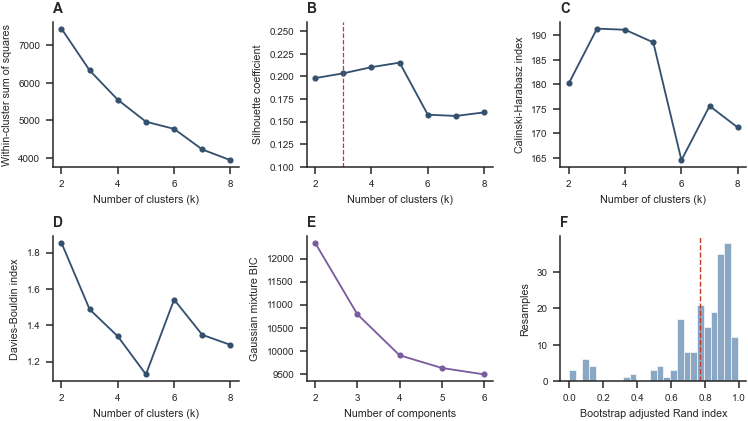

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


eFigure_2_alternative_methods: 8197x2784 px | 6.83 in wide @ 1200 dpi | mode=RGB


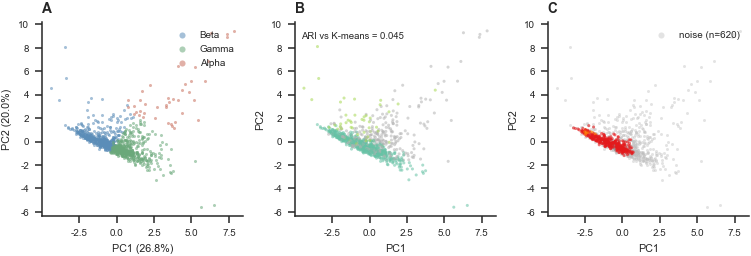

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


eFigure_3_marker_distributions: 8174x4823 px | 6.81 in wide @ 1200 dpi | mode=RGB


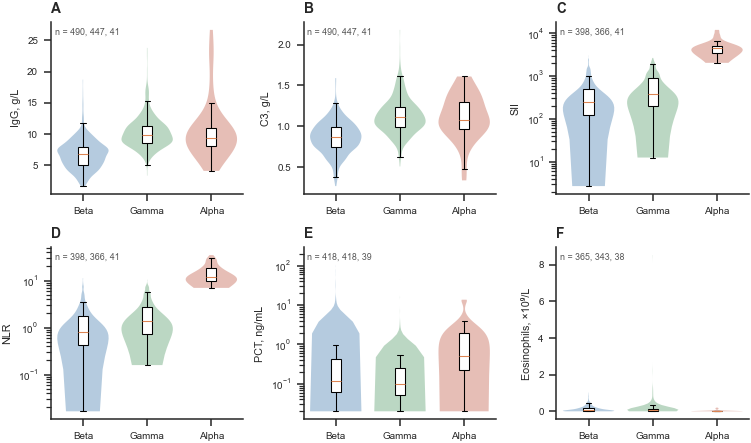

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


eFigure_4_marker_space_and_organ_values: 8173x2589 px | 6.81 in wide @ 1200 dpi | mode=RGB


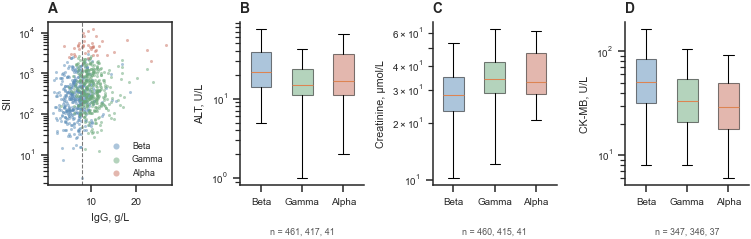

eFigure_7_forest_plot: 8200x2276 px | 6.83 in wide @ 1200 dpi | mode=RGB


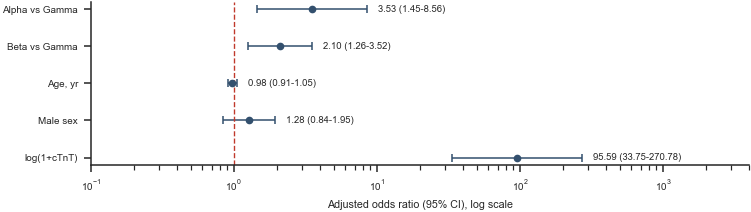

eFigure_6_marker_correlations: 4931x3401 px | 4.11 in wide @ 1200 dpi | mode=RGB


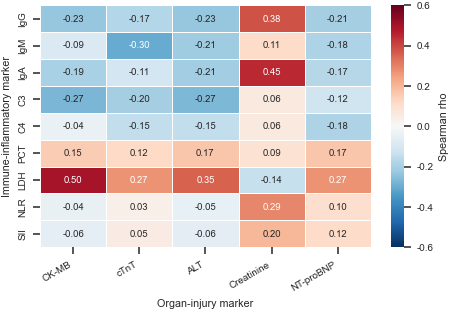

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


eFigure_5_neutrophil_eosinophil: 5815x3096 px | 4.85 in wide @ 1200 dpi | mode=RGB


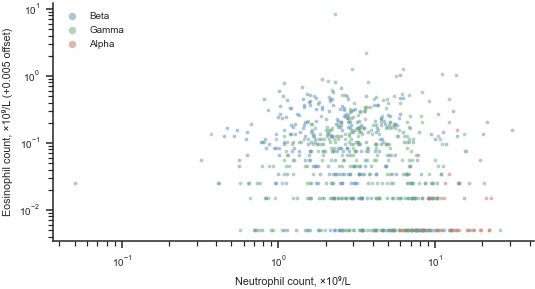

In [37]:
SHORT = {'Beta: Lower-Humoral-Marker': 'Beta',
         'Gamma: Intermediate-Marker': 'Gamma',
         'Alpha: High-Inflammation-Marker': 'Alpha'}
SHORT_ORDER = [SHORT[g] for g in ORDER]
PATTERN_COLOR = {'Beta': '#5b8db8', 'Gamma': '#6aa87a', 'Alpha': '#c9705f'}


def panel(ax, letter):
    ax.set_title(letter, loc='left', fontsize=9, weight='bold')


def observed(group_full, col):
    """Observed (non-imputed) values for one marker pattern."""
    return raw.loc[raw.Cluster_Name == group_full, col].dropna()


# ---- eFigure 1: cluster-number diagnostics and bootstrap stability ---------
fig, axes = plt.subplots(2, 3, figsize=(PRINT_WIDTH_FULL, 4.0))
cv = cluster_validation_df
for ax, col, ylab, L in [
        (axes[0, 0], 'WCSS', 'Within-cluster sum of squares', 'A'),
        (axes[0, 1], 'Silhouette', 'Silhouette coefficient', 'B'),
        (axes[0, 2], 'Calinski_Harabasz', 'Calinski-Harabasz index', 'C'),
        (axes[1, 0], 'Davies_Bouldin', 'Davies-Bouldin index', 'D')]:
    ax.plot(cv['k'], cv[col], 'o-', color='#33506e', ms=3)
    ax.set_xlabel('Number of clusters (k)'); ax.set_ylabel(ylab)
    panel(ax, L)
axes[0, 1].axvline(3, ls='--', lw=0.8, color='#c0392b')
axes[0, 1].set_ylim(0.10, 0.26)
axes[1, 1].plot([t[0] for t in gmm_bics], [t[1] for t in gmm_bics], 'o-',
                color='#7a5c9e', ms=3)
axes[1, 1].set_xlabel('Number of components'); axes[1, 1].set_ylabel('Gaussian mixture BIC')
panel(axes[1, 1], 'E')
axes[1, 2].hist(aris, bins=25, color='#8aa8c4', edgecolor='white', linewidth=0.4)
axes[1, 2].axvline(aris.mean(), ls='--', lw=0.9, color='#c0392b')
axes[1, 2].set_xlabel('Bootstrap adjusted Rand index'); axes[1, 2].set_ylabel('Resamples')
panel(axes[1, 2], 'F')
for ax in axes.ravel():
    sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, 'eFigure_1_cluster_diagnostics')
plt.show()

# ---- eFigure 2: alternative unsupervised methods and PCA ------------------
fig, axes = plt.subplots(1, 3, figsize=(PRINT_WIDTH_FULL, 2.5))
for g in ORDER:
    m = (analysis_df['Cluster_Name'] == g).values
    axes[0].scatter(pcs[m, 0], pcs[m, 1], s=4, alpha=0.55,
                    color=PATTERN_COLOR[SHORT[g]], label=SHORT[g], linewidths=0)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(frameon=False, markerscale=2, loc='upper right')
panel(axes[0], 'A')

axes[1].scatter(pcs[:, 0], pcs[:, 1], s=4, alpha=0.55, c=gmm_labels,
                cmap='Set2', linewidths=0)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].text(0.03, 0.95, f'ARI vs K-means = {ari_gmm:.3f}',
             transform=axes[1].transAxes, fontsize=6.2, va='top')
panel(axes[1], 'B')

noise = db.labels_ == -1
axes[2].scatter(pcs[noise, 0], pcs[noise, 1], s=4, alpha=0.4, color='#bbbbbb',
                label=f'noise (n={noise.sum()})', linewidths=0)
axes[2].scatter(pcs[~noise, 0], pcs[~noise, 1], s=4, alpha=0.6,
                c=db.labels_[~noise], cmap='Set1', linewidths=0)
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(frameon=False, markerscale=2, loc='upper right')
panel(axes[2], 'C')
for ax in axes:
    sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, 'eFigure_2_alternative_methods')
plt.show()

# ---- eFigure 3: distribution of panel markers (observed values) -----------
SHOW = [('IgG', 'IgG, g/L', False), ('C3', 'C3, g/L', False),
        ('SII', 'SII', True), ('NLR', 'NLR', True),
        ('PCT', 'PCT, ng/mL', True), ('EOS', 'Eosinophils, \u00d710\u2079/L', False)]
fig, axes = plt.subplots(2, 3, figsize=(PRINT_WIDTH_FULL, 4.2))
for ax, (v, ylab, logscale), L in zip(axes.ravel(), SHOW, 'ABCDEF'):
    data = [observed(g, v) for g in ORDER]
    parts = ax.violinplot(data, showextrema=False, widths=0.8)
    for pc, g in zip(parts['bodies'], SHORT_ORDER):
        pc.set_facecolor(PATTERN_COLOR[g]); pc.set_alpha(0.45); pc.set_edgecolor('none')
    bp = ax.boxplot(data, widths=0.16, showfliers=False, patch_artist=True)
    for box in bp['boxes']:
        box.set(facecolor='white', linewidth=0.7)
    for el in ('whiskers', 'caps', 'medians'):
        for ln in bp[el]:
            ln.set_linewidth(0.7)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(SHORT_ORDER)
    ax.set_ylabel(ylab)
    if logscale:
        ax.set_yscale('log')
    ax.text(0.02, 0.97, 'n = ' + ', '.join(str(len(d)) for d in data),
            transform=ax.transAxes, fontsize=5.8, va='top', color='#555555')
    sns.despine(ax=ax); panel(ax, L)
fig.tight_layout()
save_figure(fig, 'eFigure_3_marker_distributions')
plt.show()

# ---- eFigure 4: marker space and organ-injury values ----------------------
fig, axes = plt.subplots(1, 4, figsize=(PRINT_WIDTH_FULL, 2.45))
for g in ORDER:
    m = raw.Cluster_Name == g
    axes[0].scatter(raw.loc[m, 'IgG'], raw.loc[m, 'SII'], s=4, alpha=0.5,
                    color=PATTERN_COLOR[SHORT[g]], label=SHORT[g], linewidths=0)
axes[0].set_yscale('log'); axes[0].set_xlabel('IgG, g/L'); axes[0].set_ylabel('SII')
axes[0].axvline(7.895, ls='--', lw=0.7, color='#777777')
axes[0].legend(frameon=False, markerscale=2, fontsize=5.8, loc='lower right')
panel(axes[0], 'A')
for ax, (v, ylab, L) in zip(axes[1:], [('ALT', 'ALT, U/L', 'B'),
                                       ('Scr', 'Creatinine, \u00b5mol/L', 'C'),
                                       ('CKMB', 'CK-MB, U/L', 'D')]):
    data = [observed(g, v) for g in ORDER]
    bp = ax.boxplot(data, widths=0.5, showfliers=False, patch_artist=True)
    for box, g in zip(bp['boxes'], SHORT_ORDER):
        box.set(facecolor=PATTERN_COLOR[g], alpha=0.5, linewidth=0.7)
    for el in ('whiskers', 'caps', 'medians'):
        for ln in bp[el]:
            ln.set_linewidth(0.7)
    ax.set_yscale('log'); ax.set_xticks([1, 2, 3]); ax.set_xticklabels(SHORT_ORDER)
    ax.set_ylabel(ylab)
    # n moved below the axis: on a log scale the boxes reach the top of the panel,
    # so the previous in-axes position at (0.02, 0.97) overlapped the data.
    ax.text(0.5, -0.26, 'n = ' + ', '.join(str(len(d)) for d in data),
            transform=ax.transAxes, fontsize=5.8, ha='center', va='top', color='#555555')
    sns.despine(ax=ax); panel(ax, L)
fig.tight_layout()
save_figure(fig, 'eFigure_4_marker_space_and_organ_values')
plt.show()

# ---- eFigure 5: adjusted associations (forest plot) -----------------------
fig, ax = plt.subplots(figsize=(PRINT_WIDTH_FULL, 2.1))
terms = ['Is_Alpha', 'Is_Beta', 'Age', 'Sex', 'log_cTnT']
term_labels = ['Alpha vs Gamma', 'Beta vs Gamma', 'Age, yr', 'Male sex', 'log(1+cTnT)']
ors = np.array([np.exp(model.params[t]) for t in terms])
lo = np.array([np.exp(model.conf_int().loc[t][0]) for t in terms])
hi = np.array([np.exp(model.conf_int().loc[t][1]) for t in terms])
ypos = np.arange(len(terms))[::-1]
ax.errorbar(ors, ypos, xerr=[ors - lo, hi - ors], fmt='o', color='#33506e',
            ecolor='#33506e', capsize=2.5, ms=4, lw=1)
ax.axvline(1, color='#c0392b', ls='--', lw=0.9)
ax.set_xscale('log'); ax.set_yticks(ypos); ax.set_yticklabels(term_labels)
ax.set_xlabel('Adjusted odds ratio (95% CI), log scale')
for o, l, h, yy in zip(ors, lo, hi, ypos):
    ax.text(h * 1.2, yy, f'{o:.2f} ({l:.2f}-{h:.2f})', va='center', fontsize=6.2)
ax.set_xlim(0.1, 4000); sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, 'eFigure_7_forest_plot')
plt.show()

# ---- eFigure 6: immune x organ-injury correlation matrix ------------------
fig, ax = plt.subplots(figsize=(PRINT_WIDTH_FULL * 0.62, 3.0))
sns.heatmap(corr_table.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6, ax=ax, annot_kws={'size': 6.2},
            cbar_kws={'label': 'Spearman rho'}, linewidths=0.4, linecolor='white')
ax.set_xticklabels(['CK-MB', 'cTnT', 'ALT', 'Creatinine', 'NT-proBNP'],
                   rotation=30, ha='right')
ax.set_xlabel('Organ-injury marker'); ax.set_ylabel('Immune-inflammatory marker')
fig.tight_layout()
save_figure(fig, 'eFigure_6_marker_correlations')
plt.show()

# ---- eFigure 7: neutrophil and eosinophil counts --------------------------
fig, ax = plt.subplots(figsize=(PRINT_WIDTH_FULL * 0.72, 2.8))
for g in ORDER:
    m = raw.Cluster_Name == g
    ax.scatter(raw.loc[m, 'NEUT'], raw.loc[m, 'EOS'] + 0.005, s=6, alpha=0.5,
               color=PATTERN_COLOR[SHORT[g]], label=SHORT[g], linewidths=0)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Neutrophil count, \u00d710\u2079/L')
ax.set_ylabel('Eosinophil count, \u00d710\u2079/L (+0.005 offset)')
ax.legend(frameon=False, markerscale=2, loc='upper left')
sns.despine(ax=ax)
fig.tight_layout()
save_figure(fig, 'eFigure_5_neutrophil_eosinophil')
plt.show()

In [38]:
# ---- Reproducibility checks --------------------------------------------
expected_counts = {'Beta: Lower-Humoral-Marker': 491,
                   'Gamma: Intermediate-Marker': 447,
                   'Alpha: High-Inflammation-Marker': 41}
assert analysis_df['Cluster_Name'].value_counts().to_dict() == expected_counts
assert len(analysis_df) == 979
assert int(analysis_df['Composite_Outcome'].sum()) == 146

# Descriptive statistics must now come from observed values, not the imputed panel.
obs_ldh = [raw.loc[raw.Cluster_Name == g, 'LDH'].dropna().median() for g in ORDER]
assert len(set(round(v, 2) for v in obs_ldh)) == 3, \
    'LDH medians are still identical across groups - imputed values leaked in'
assert abs(raw.loc[raw.Cluster_Name == ORDER[0], 'SII'].dropna().median() -
           raw.loc[raw.Cluster_Name == ORDER[1], 'SII'].dropna().median()) > 1, \
    'Beta and Gamma SII medians are still identical'

# Every exported figure must be RGB at 1,200 dpi, exist as vector EPS, and fit the column.
from PIL import Image as _Image
MAIN_FIGURES = ['Figure_1', 'Figure_2', 'Figure_3']
SUPP_FIGURES = ['eFigure_1_cluster_diagnostics', 'eFigure_2_alternative_methods',
                'eFigure_3_marker_distributions', 'eFigure_4_marker_space_and_organ_values',
                'eFigure_5_neutrophil_eosinophil', 'eFigure_6_marker_correlations',
                'eFigure_7_forest_plot']
for stem in MAIN_FIGURES + SUPP_FIGURES:
    _im = _Image.open(FIG_DIR / f'{stem}.tiff')
    assert _im.mode == 'RGB', f'{stem} is not RGB'
    assert abs(float(_im.info.get('dpi', (0, 0))[0]) - EXPORT_DPI) < 1, f'{stem} is not tagged {EXPORT_DPI} dpi'
    assert _im.size[0] / EXPORT_DPI <= 7.05, f'{stem} exceeds the printed column width'
    assert (FIG_DIR / f'{stem}.eps').exists(), f'{stem}.eps (vector) missing'

print(f'Verified {len(MAIN_FIGURES)} main and {len(SUPP_FIGURES)} supplemental figures.')
print('REPRODUCIBILITY CHECKS PASSED: cohort, cluster counts, event count,')
print('observed-value descriptives, and publication-ready figure export.')

Verified 3 main and 7 supplemental figures.
REPRODUCIBILITY CHECKS PASSED: cohort, cluster counts, event count,
observed-value descriptives, and publication-ready figure export.
